In [1]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
#load the data
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

df.columns = ['ID', 'Gender', 'Age', 'Income', 'SpendingScore']
df.head()

,ID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Selecting columns: Annual Income and Spending Score
X = df.iloc[:, [3, 4]].values

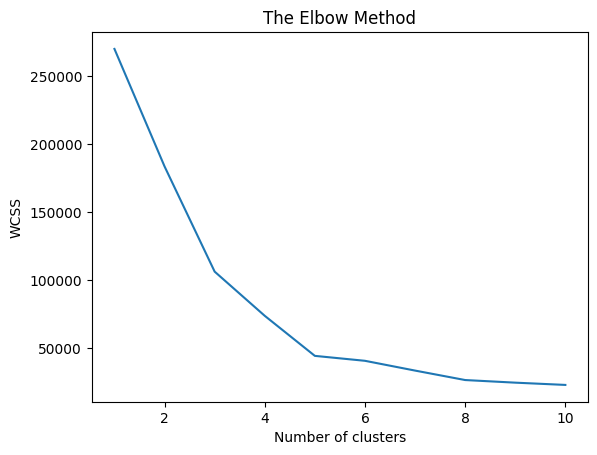

In [4]:
#finding optimal clusters (using the elbow method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
#training the model using 5 as k
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels back to our original dataframe
df['Cluster'] = y_kmeans

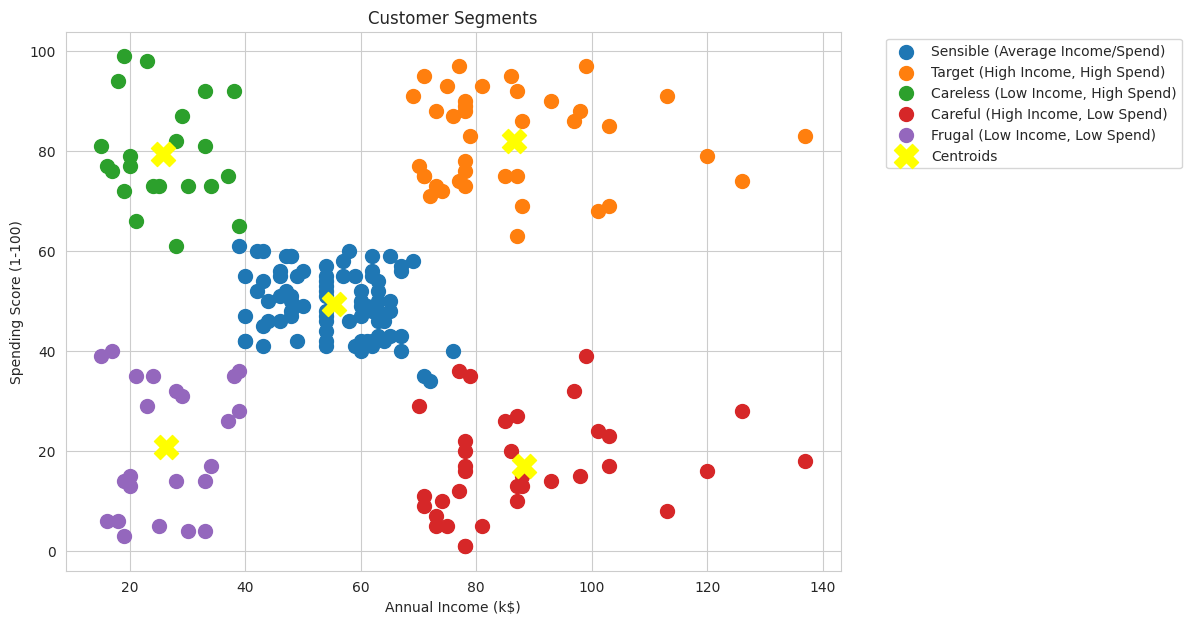

In [17]:
#cluster visualization
centers = kmeans.cluster_centers_ # Added this line to define centers
labels = {}
for i, center in enumerate(centers):
    income, spending = center[0], center[1]

    # Logic to identify which cluster is which based on coordinates
    if income > 70 and spending > 70:
        labels[i] = 'Target (High Income, High Spend)'
    elif income > 70 and spending < 40:
        labels[i] = 'Careful (High Income, Low Spend)'
    elif income < 40 and spending > 70:
        labels[i] = 'Careless (Low Income, High Spend)'
    elif income < 40 and spending < 40:
        labels[i] = 'Frugal (Low Income, Low Spend)'
    else:
        labels[i] = 'Sensible (Average Income/Spend)'

plt.figure(figsize=(10, 7))
for i in range(5):
    # Plotting each cluster using the dynamically assigned label
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=100, label=labels[i])

# Plot the centroids as large 'X' markers
plt.scatter(centers[:, 0], centers[:, 1], s=300, c='yellow', marker='X', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.show()

/tmp/ipykernel_13253/2644410886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Age', data=df, palette='viridis')


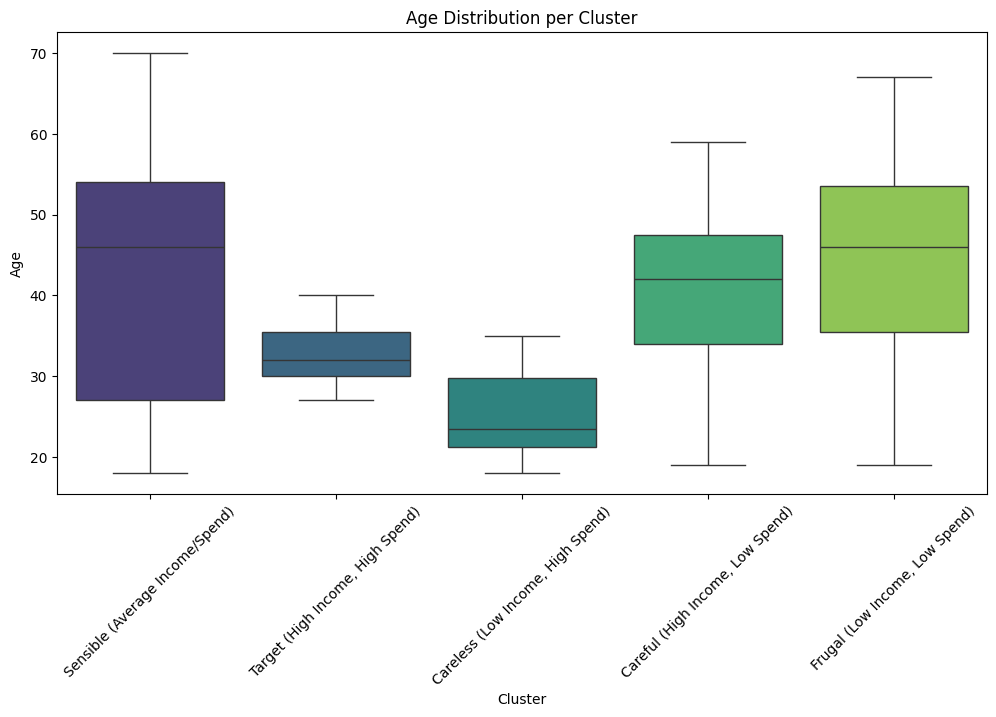

In [11]:
#age distribution per cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Age', data=df, palette='viridis')
plt.title('Age Distribution per Cluster')
plt.xticks(ticks=range(5), labels=[labels[i] for i in range(5)], rotation=45)
plt.show()

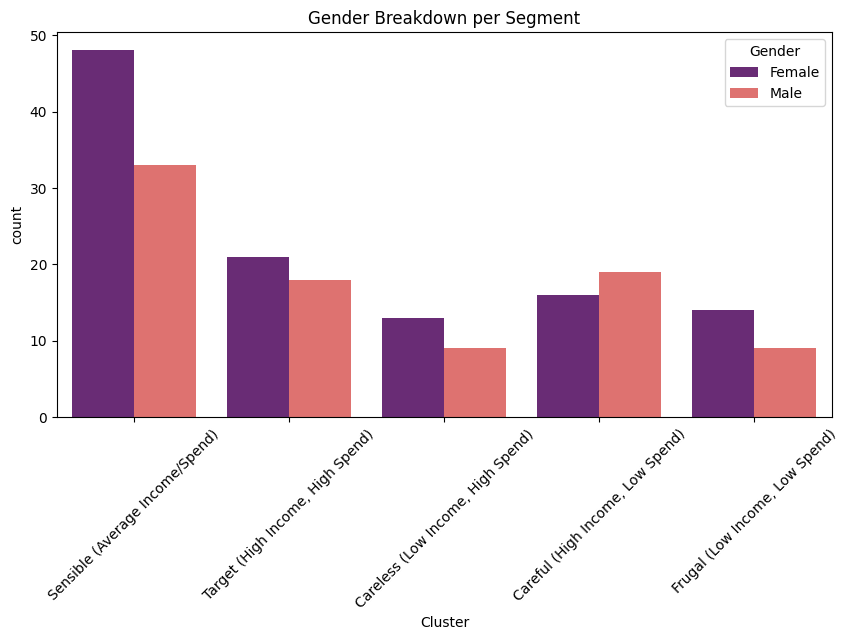

In [12]:
#gender breakdown
plt.figure(figsize=(10, 5))
sns.countplot(x='Cluster', hue='Gender', data=df, palette='magma')
plt.title('Gender Breakdown per Segment')
plt.xticks(ticks=range(5), labels=[labels[i] for i in range(5)], rotation=45)
plt.show()

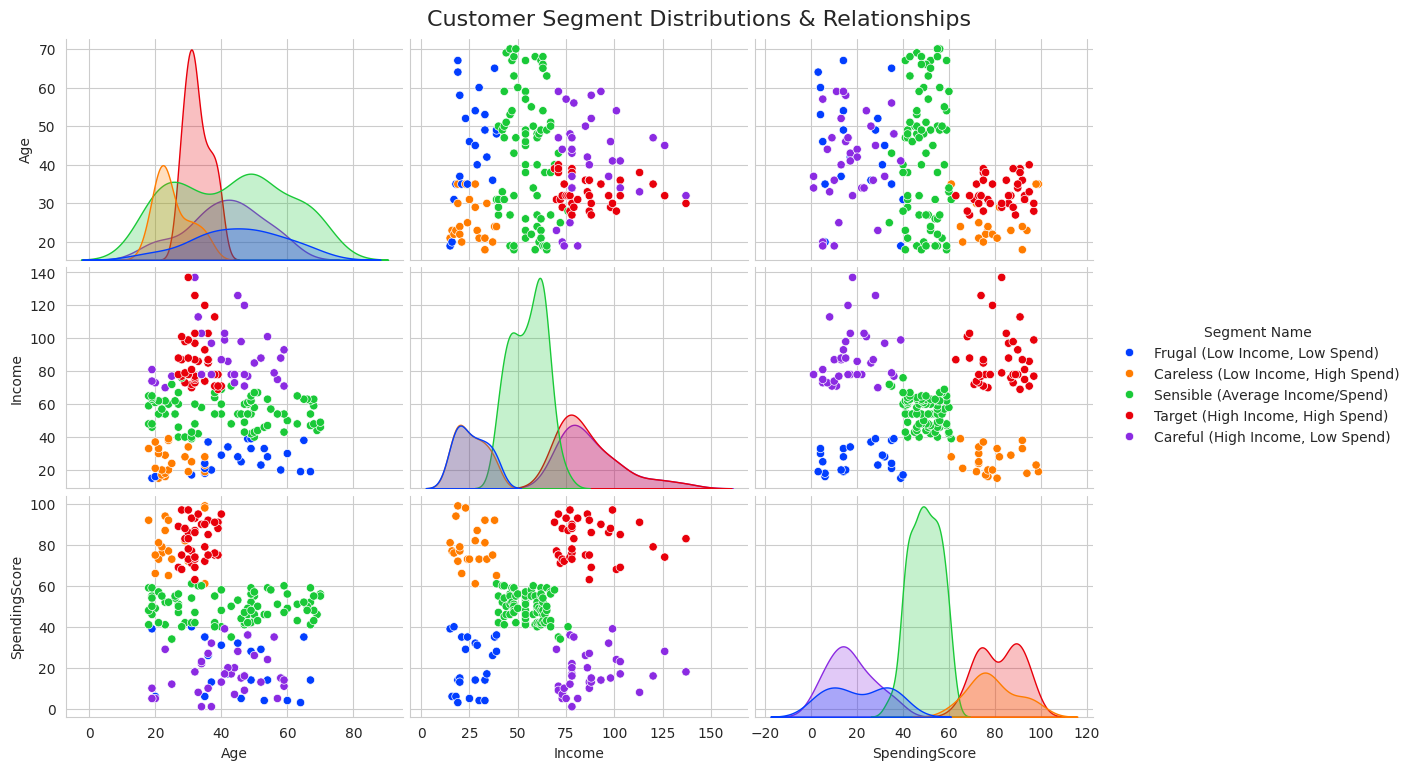

In [16]:
#EDA (exploratory data Analysis)

df['Segment Name'] = df['Cluster'].map(labels)

sns.set_style("whitegrid")
g = sns.pairplot(
    df.drop(['ID', 'Cluster'], axis=1),
    hue='Segment Name',
    palette='bright',
    aspect=1.5,
    diag_kind='kde'
)

#Add a title
g.fig.suptitle('Customer Segment Distributions & Relationships', y=1.02, fontsize=16)

plt.show()